# Melt-Quench Tutorial

This notebook walks through the full melt-quench workflow in **amorphouspy**: from composition input and interatomic potential selection through simulation setup, execution, and results inspection.

Sections:
1. Interatomic potentials — theory, supported elements, charges, and when to use each
2. Automatic potential selection
3. Structure generation
4. Potential generation
5. Melt-quench simulation — protocols and parameters
6. Post-processing and plotting
7. Quick reference

In [1]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


import amorphouspy as am
from amorphouspy.potentials.potential import (
    compatible_potentials,
    generate_potential,
    get_supported_elements,
    select_potential,
)

## 1. Interatomic Potentials

amorphouspy ships three force-field models for oxide glass simulations. All three use a **Damped Shifted Force (DSF)** Coulomb treatment for long-range electrostatics and differ only in the short-range pair interaction.

| Potential | Pair style | Elements | Default T_melt |
|-----------|-----------|----------|---------------|
| **PMMCS** (Pedone) | Morse + Coulomb/DSF | 29 elements (see below) | 5000 K |
| **SHIK** (Sundararaman) | Buckingham + r⁻²⁴ + Coulomb/DSF | 9 elements | 4000 K |
| **BJP** (Bouhadja) | Born-Mayer-Huggins + Coulomb/DSF | Ca, Al, Si, O | 5000 K |

Selection rule applied by `select_potential`: PMMCS → SHIK → BJP (first that covers all elements).

### 1.1 PMMCS Potential (Pedone et al.)

**References**  
- Pedone et al., *J. Phys. Chem. B* **110**, 11780 (2006) — original parameterisation  

**Functional form** — Morse + repulsive term + Coulomb DSF:

$$V_{ij}(r) = D_{ij}\left[e^{-2a_{ij}(r - r_0)} - 2e^{-a_{ij}(r - r_0)}\right] + \frac{C_{ij}}{r^{12}} + \frac{q_i q_j}{r}$$

LAMMPS pair style: `hybrid/overlay coul/dsf 0.25 8.0 pedone 5.5`

**Partial charges** (formal charges scaled to 0.5×):

| Element | Charge *e* |
|---------|-----------|
| O | −1.2 |
| Li, Na, K, Cu, Ag | +0.6 |
| Be, Mg, Ca, Sr, Ba, Mn, Fe, Co, Ni, Zn | +1.2 |
| Sc, Cr, Al, Fe3, Nd, Gd, Er | +1.8 |
| Ti, Zr, Si, Ge, Sn | +2.4 |
| P | +3.0 |

**Supported elements (29):**

| Group | Elements |
|-------|---------|
| Alkali | Li, Na, K |
| Alkaline-earth | Be, Mg, Ca, Sr, Ba |
| Transition metals | Sc, Ti, Cr, Mn, Fe (Fe²⁺ / Fe³⁺), Co, Ni, Cu, Zn, Zr, Ag |
| Network formers | Al, Si, Ge, Sn, P |
| Rare-earth | Nd, Gd, Er |
| Anion | O |

**When to use:** Broadest element coverage. The default choice for silicate, borate, phosphate, and mixed-modifier glasses. Suitable for most compositions without transition metals requiring charge-transfer.

**Limitation:** Does not include B.

### 1.2 SHIK Potential (Sundararaman et al.)

**References**  
- Sundararaman et al., *J. Chem. Phys.* **148**, 194504 (2018) — SiO₂  
- Sundararaman et al., *J. Chem. Phys.* **150**, 154505 (2019) — alkali and alkaline-earth aluminosilicate  
- Sundararaman et al., *J. Chem. Phys.* **152**, 104501 (2020) — borate with mixed network formers  
- Shih et al., *J. Non-Cryst. Sol.* **565**, 120853 (2021) — alkaline-earth silicate and borate  

**Functional form** — Buckingham + r⁻²⁴ + Coulomb DSF:

$$V_{ij}(r) = A_{ij}\,e^{-B_{ij} r} - \frac{C_{ij}}{r^6} + \frac{D_{ij}}{r^{24}} + \frac{q_i q_j}{r}$$

The r⁻²⁴ term acts as a steep repulsive wall that improves stability at very short distances compared to a standard Buckingham potential.

LAMMPS pair style: `hybrid/overlay coul/dsf 0.2 10.0 table spline 10000`

> **Note:** SHIK uses **tabulated** pair coefficients. `generate_shik_potential()` writes one `.tbl` file per pair to disk and embeds absolute paths in the LAMMPS input. The `output_dir` argument controls where these files land.

**Partial charges** (non-integer, composition-dependent):

| Element | Charge *e* |
|---------|-----------|
| Li | +0.5727 |
| Na | +0.6018 |
| K | +0.6849 |
| Mg | +1.0850 |
| Ca | +1.4977 |
| B | +1.6126 |
| Al | +1.6334 |
| Si | +1.7755 |
| O | computed for charge neutrality |

**Supported elements (9):** Li, Na, K, Mg, Ca, B, Al, Si, O

**When to use:** Preferred for **borosilicate**, boroaluminosilicate, and alkali-silicate glasses, where B must be included. Highly validated for SiO₂. More limited element set than PMMCS.

**Limitation:** Only 9 elements; SHIK protocol initialises with a Langevin + NVE/limit pre-melt block at 5000 K (included automatically when `melt=True`, stripped in later protocol stages).

**Special SHIK protocol note:** Default `temperature_high = 4000 K` (lower than the others because the potential was parameterised with this ceiling in mind).

### 1.3 BJP Potential (Bouhadja et al.)

**References**  
- Bouhadja et al., *J. Chem. Phys.* **138**, 224510 (2013) — CaO-Al₂O₃-SiO₂  

**Functional form** — Born-Mayer-Huggins (BMH) + Coulomb DSF:

$$V_{ij}(r) = A_{ij}\,e^{(r_{ij} - r)/\rho_{ij}} - \frac{C_{ij}}{r^6} - \frac{D_{ij}}{r^8} + \frac{q_i q_j}{r}$$

LAMMPS pair style: `born/coul/dsf 0.25 8.0`

**Charges** (scaled formal charges):

| Element | Charge *e* |
|---------|-----------|
| O | −1.2 |
| Ca | +1.2 |
| Al | +1.8 |
| Si | +2.4 |

**Supported elements (4):** Ca, Al, Si, O

**When to use:** Specifically developed and validated for **calcium aluminosilicate (CAS) glasses**. Best choice when studying CaO-Al₂O₃-SiO₂ with maximum fidelity to the original parameterisation.

**Limitation:** Very narrow element set — strictly Ca/Al/Si/O. Any other element will cause validation to fail.

## 2. Automatic Potential Selection

`select_potential(elements)` returns the best available potential name for a given element set (preference order: PMMCS → SHIK → BJP).  
`compatible_potentials(elements)` returns all compatible names.

In [2]:
# Inspect supported elements per potential
for name in ("pmmcs", "shik", "bjp"):
    elems = sorted(get_supported_elements(name))
    print(f"{name.upper():6s} ({len(elems)} elements): {', '.join(elems)}")

print()

# Automatic selection for different glass families
examples = {
    "Na₂O-SiO₂ (soda-silicate)": {"Na", "Si", "O"},
    "Na₂O-B₂O₃-SiO₂ (borosilicate)": {"Na", "B", "Si", "O"},
    "CaO-Al₂O₃-SiO₂ (CAS)": {"Ca", "Al", "Si", "O"},
    "ZrO₂-SiO₂ (zircosilicate)": {"Zr", "Si", "O"},
}
print(f"{'Composition':<40} {'Best':>6}  All compatible")
print("-" * 65)
for label, elements in examples.items():
    best = select_potential(elements)
    all_compat = compatible_potentials(elements)
    print(f"{label:<40} {best!s:>6}  {all_compat}")

PMMCS  (29 elements): Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr
SHIK   (9 elements): Al, B, Ca, K, Li, Mg, Na, O, Si
BJP    (4 elements): Al, Ca, O, Si

Composition                                Best  All compatible
-----------------------------------------------------------------
Na₂O-SiO₂ (soda-silicate)                 pmmcs  ['pmmcs', 'shik']
Na₂O-B₂O₃-SiO₂ (borosilicate)              shik  ['shik']
CaO-Al₂O₃-SiO₂ (CAS)                      pmmcs  ['pmmcs', 'shik', 'bjp']
ZrO₂-SiO₂ (zircosilicate)                 pmmcs  ['pmmcs']


## 3. Structure Generation

`get_structure_dict` builds the internal representation (a dict with `"atoms"` and `"box"` keys) from an oxide composition.  
`get_ase_structure` converts that dict to an ASE `Atoms` object needed by the simulation functions.

The composition is specified as a dictionary of oxide formulas → molar fractions.

In [3]:
# Example: 25 CaO - 25 Al2O3 - 50 SiO2 (mol%)
composition = {"CaO": 0.25, "Al2O3": 0.25, "SiO2": 0.50}

struct_dict = am.get_structure_dict(composition, target_atoms=500)
print("Box length:", struct_dict["box"], "Å")
print("Atom count:", len(struct_dict["atoms"]))

counts = Counter(a["element"] for a in struct_dict["atoms"])
print("Element counts:", dict(counts))

Box length: 18.759772823007427 Å
Atom count: 499
Element counts: {'Ca': 39, 'O': 307, 'Al': 76, 'Si': 77}


In [4]:
# Convert to ASE Atoms object
atoms = am.get_ase_structure(struct_dict)
print(atoms)
print("Cell:", atoms.cell.array.diagonal().tolist(), "Å")
print("PBC:", atoms.pbc)

Atoms(symbols='Al76Ca39O307Si77', pbc=True, cell=[18.759772823007427, 18.759772823007427, 18.759772823007427], id=..., initial_charges=..., masses=..., mmcharges=..., type=...)
Cell: [18.759772823007427, 18.759772823007427, 18.759772823007427] Å
PBC: [ True  True  True]


## 4. Potential Generation

`generate_potential(atoms_dict, potential_type)` returns a `pd.DataFrame` with columns:

| Column | Content |
|--------|---------|
| `Name` | Potential name (`"PMMCS"`, `"SHIK"`, `"BJP"`) |
| `Model` | Full model descriptor string |
| `Species` | List of element symbols in the structure |
| `Config` | List of LAMMPS input lines |
| `Filename` | Table file paths (SHIK only; empty list for PMMCS/BJP) |

The `Config` lines are injected directly before the LAMMPS run commands by the simulation engine.

In [5]:
# Generate BJP potential (CAS system)
potential_bjp = generate_potential(struct_dict, potential_type="bjp")
print(potential_bjp[["Name", "Model", "Species"]])
print()
print("--- LAMMPS config lines ---")
for line in potential_bjp.loc[0, "Config"]:
    print(line, end="")

  Name                           Model          Species
0  BJP  Born-Mayer-Huggins_coulomb_DSF  [Al, Ca, O, Si]

--- LAMMPS config lines ---
# Bouhadja et al., J. Chem. Phys. 138, 224510 (2013) 
units metal
dimension 3
atom_style charge

# create groups ###
group Al type 1
group Ca type 2
group O type 3
group Si type 4

### set charges ###
set type 1 charge 1.8
set type 2 charge 1.2
set type 3 charge -1.2
set type 4 charge 2.4

### Bouhadja Born-Mayer-Huggins + Coulomb Potential Parameters ###
pair_style born/coul/dsf 0.25 8.0
pair_coeff 1 1 0.002900 0.068000 1.570400 14.049800 0.000000
pair_coeff 1 2 0.003200 0.074000 1.957200 17.171000 0.000000
pair_coeff 1 3 0.007500 0.164000 2.606700 34.574700 0.000000
pair_coeff 1 4 0.002500 0.057000 1.505600 18.811600 0.000000
pair_coeff 2 2 0.003500 0.080000 2.344000 20.985600 0.000000
pair_coeff 2 3 0.007700 0.178000 2.993500 42.255600 0.000000
pair_coeff 2 4 0.002700 0.063000 1.892400 22.990700 0.000000
pair_coeff 3 3 0.012000 0.263000 3.64300

In [6]:
# Generate PMMCS potential for the same system
potential_pmmcs = generate_potential(struct_dict, potential_type="pmmcs")
print("--- PMMCS config lines ---")
for line in potential_pmmcs.loc[0, "Config"]:
    print(line, end="")

--- PMMCS config lines ---
# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Al type 1
group Ca type 2
group O type 3
group Si type 4

### set charges ###
set type 1 charge 1.8
set type 2 charge 1.2
set type 3 charge -1.2
set type 4 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/dsf 0.25 8.0 pedone 5.5
pair_coeff * * coul/dsf
pair_coeff 1 3 pedone 0.361581 1.900442 2.164818 0.9
pair_coeff 2 3 pedone 0.030211 2.241334 2.923245 5.0
pair_coeff 3 3 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 4 3 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes

fix langevinnve all langevin 4000 4000 0.01 48279

fix ensemblenve all nve/limit 0.5

run 10000

unfix langevinnve

unfix ensemblenve


### 4.1 Custom electrostatics settings

By default all three potentials use **DSF** (Damped Shifted Force) Coulomb with their built-in cutoffs and damping parameter `α`. Pass an `ElectrostaticsConfig` to override any of these:

| Field | Default (DSF) | Description |
|-------|--------------|-------------|
| `method` | `"dsf"` | Coulomb solver: `"dsf"`, `"wolf"`, `"pppm"`, `"ewald"` |
| `short_range_cutoff` | potential-specific | Pair-potential cutoff (Å). BJP ignores this field. |
| `long_range_cutoff` | potential-specific | Coulomb cutoff (Å). Ignored by BJP. |
| `alpha` | potential-specific | Damping parameter (Å⁻¹) for DSF / Wolf |
| `kspace_accuracy` | `1e-5` | Relative accuracy for PPPM / Ewald |

`"pppm"` and `"ewald"` append a `kspace_style` line and do not use `alpha`.

In [ ]:
from amorphouspy.potentials.potential import ElectrostaticsConfig

# --- BJP: wider short-range cutoff + stronger damping ---
cfg_bjp_custom = ElectrostaticsConfig(short_range_cutoff=10.0, alpha=0.20)
pot_bjp_custom = generate_potential(struct_dict, potential_type="bjp", melt=False, electrostatics=cfg_bjp_custom)
pair_style_line = next(line for line in pot_bjp_custom.loc[0, "Config"] if "pair_style" in line)
print("BJP custom DSF:", pair_style_line.strip())

# --- BJP: Wolf method instead of DSF ---
cfg_bjp_wolf = ElectrostaticsConfig(method="wolf", short_range_cutoff=10.0, alpha=0.20)
pot_bjp_wolf = generate_potential(struct_dict, potential_type="bjp", melt=False, electrostatics=cfg_bjp_wolf)
pair_style_line = next(line for line in pot_bjp_wolf.loc[0, "Config"] if "pair_style" in line)
print("BJP Wolf:      ", pair_style_line.strip())

# --- PMMCS: PPPM instead of DSF (appends a kspace_style line) ---
cfg_pmmcs_pppm = ElectrostaticsConfig(method="pppm", long_range_cutoff=12.0, kspace_accuracy=1e-6)
pot_pmmcs_pppm = generate_potential(struct_dict, potential_type="pmmcs", melt=False, electrostatics=cfg_pmmcs_pppm)
config_lines = pot_pmmcs_pppm.loc[0, "Config"]
for line in config_lines:
    if "pair_style" in line or "kspace_style" in line:
        print("PMMCS PPPM:    ", line.strip())

In [8]:
# SHIK potential — writes .tbl files to output_dir
# The table files encode V(r) and F(r) on a fine grid for each pair
from amorphouspy.potentials.shik_potential import generate_shik_potential

# Use a borosilicate composition to exercise the B parameters
struct_dict_bs = am.get_structure_dict(
    {"Na2O": 0.1, "CaO": 0.05, "B2O3": 0.10, "Al2O3": 0.05, "SiO2": 0.7}, target_atoms=300
)
potential_shik = generate_shik_potential(struct_dict_bs, output_dir="./shik_tables", melt=True)
print(potential_shik[["Name", "Model", "Species"]])
print()
print("--- SHIK config lines ---")
for line in potential_shik.loc[0, "Config"]:
    print(line, end="")

   Name Model                 Species
0  SHIK  SHIK  [Al, B, Ca, Na, O, Si]

--- SHIK config lines ---
# S. Sundararaman et al.,
# for silica glass, J. Chem. Phys. 2018, 148, 19, https://doi.org/10.1063/1.5023707
# for alkali and alkaline-earth aluminosilicate glasses, J. Chem. Phys. 2019, 150, 15, https://doi.org/10.1063/1.5079663
# for borate glasses with mixed network formers, J. Chem. Phys. 2020, 152, 10, https://doi.org/10.1063/1.5142605
# for alkaline earth silicate and borate glasses, Shih et al. J. Non-Cryst. Sol. 2021, 565, 120853, https://doi.org/10.1016/j.jnoncrysol.2021.120853

dimension 3
atom_style charge


### Group Definitions ###
group Al type 1
group B type 2
group Ca type 3
group Na type 4
group O type 5
group Si type 6

### Charges ###
set type 1 charge 1.6334
set type 2 charge 1.6126
set type 3 charge 1.4977
set type 4 charge 0.6018
set type 5 charge -0.9636614130434783
set type 6 charge 1.7755

### SHIK Potential ###
pair_style hybrid/overlay coul/dsf 0.2 10.0 tab

## 5. Melt-Quench Simulation

`melt_quench_simulation` runs a multi-stage protocol that:
1. Heats the random structure to `temperature_high`
2. Equilibrates the melt
3. Cools to `temperature_low` at the specified `cooling_rate`
4. Releases pressure (NPT at 0 GPa)
5. Final NVT equilibration at room temperature

Each potential has a dedicated protocol with different ensemble choices and stage durations. These differ because the potentials have different stability characteristics.

### Protocol comparison

| Stage | PMMCS | SHIK | BJP |
|-------|-------|------|-----|
| 1 Heating | NVT ramp T_low → T_high | NVT from T_high (with Langevin+NVE/limit init) | NPT ramp T_low → T_high |
| 2 Melt equil. | NVT, 1 M steps (default) | NVT, 100 ps | NPT, 100k steps |
| 3 NPT equil. | — | NPT 0.1 GPa, 700 ps | — |
| 4 Quench | NVT ramp T_high → T_low | NPT quench, pressure 0.1→0 GPa | NPT ramp T_high → T_low |
| 5 Pressure release | NPT 0 GPa, 1 M steps | — | NPT 0 GPa, 100k steps |
| 6 Final equil. | NVT, 100k steps | NPT 0 GPa, 100 ps | NVT, 100k steps |

### Key parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `temperature_high` | PMMCS/BJP: 5000 K, SHIK: 4000 K | Melt temperature |
| `temperature_low` | 300 K | Final glass temperature |
| `timestep` | 1.0 fs | MD integration timestep |
| `heating_rate` | 1×10¹² K/s | Rate for heating ramp |
| `cooling_rate` | 1×10¹² K/s | Rate for quenching ramp |
| `equilibration_steps` | None (protocol defaults) | Override all equilibration stages |
| `n_print` | 1000 | Output frequency (steps) |
| `langevin` | False | Use Langevin thermostat |
| `seed` | 12345 | Velocity initialisation seed |

### Step count calculation

The number of heating/cooling steps is derived from the rate:

```
steps = ΔT / (timestep [fs] × rate [K/s]) × 1e15 [fs/s]
```

For example, with ΔT = 4700 K, timestep = 1 fs, and rate = 1×10¹² K/s:
```
steps = 4700 / (1×10⁻¹⁵ × 1×10¹²) = 4 700 000 steps  (~4.7 ns)
```

A faster rate (e.g. 1×10¹³ K/s) gives 10× fewer steps and a shorter simulation.

In [9]:
result = am.melt_quench_simulation(
    structure=atoms,
    potential=potential_shik,
    temperature_high=5000.0,
    temperature_low=300.0,
    timestep=1.0,
    heating_rate=1e15,  # fast for demonstration
    cooling_rate=1e15,
    n_print=500,
    equilibration_steps=5000,  # override protocol defaults — production: remove this line
    seed=42,
)

glass = result["structure"]
history = result["result"]  # list[dict | None], one entry per protocol stage
print("Final structure:", glass)
print(f"Protocol stages: {len(history)}")
for i, stage in enumerate(history):
    keys = list(stage.keys()) if stage else None
    print(f"  Stage {i + 1}: {keys}")

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity LogStep. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalize

Final structure: Atoms(symbols='Al76Ca39O307Si77', pbc=True, cell=[[19.946287255019723, 3.664073526260032e-15, 3.664073526260032e-15], [-2.442715684173355e-15, 19.946287255019723, 3.6640735262600315e-15], [-2.442715684173354e-15, -2.442715684173355e-15, 19.946287255019723]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
Protocol stages: 5
  Stage 1: ['steps', 'natoms', 'cells', 'indices', 'forces', 'velocities', 'unwrapped_positions', 'positions', 'temperature', 'energy_pot', 'energy_tot', 'volume', 'LogStep', 'pressures']
  Stage 2: ['steps', 'natoms', 'cells', 'indices', 'forces', 'velocities', 'unwrapped_positions', 'positions', 'temperature', 'energy_pot', 'energy_tot', 'volume', 'pressures']
  Stage 3: ['steps', 'natoms', 'cells', 'indices', 'forces', 'velocities', 'unwrapped_positions', 'positions', 'temperature', 'energy_pot', 'energy_tot', 'volume', 'pressures']
  Stage 4: ['steps', 'natoms', 'cells', 'indices', 'forces', 'velocitie

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


### Parallel runs with executorlib

For multiple independent compositions or cooling rates, use `executorlib.SingleNodeExecutor` to dispatch jobs as futures.

```
from executorlib import SingleNodeExecutor

compositions = {
    "CAS_25_25_50": {"CaO": 0.25, "Al2O3": 0.25, "SiO2": 0.50},
    "CAS_30_10_60": {"CaO": 0.30, "Al2O3": 0.10, "SiO2": 0.60},
}


def run_one(label, comp):
    sd = am.get_structure_dict(comp, target_atoms=500)
    pot = generate_potential(sd, potential_type="bjp")
    ase = am.get_ase_structure(sd)
    res = am.melt_quench_simulation(
        structure=ase,
        potential=pot,
        heating_rate=1e15,
        cooling_rate=1e15,
        equilibration_steps=5000,
        seed=42,
    )
    return label, res["structure"]


with SingleNodeExecutor(max_workers=2) as exe:
    futures = {label: exe.submit(run_one, label, comp) for label, comp in compositions.items()}

results = {label: fut.result() for label, fut in futures.items()}
for label, (_name, struct) in results.items():
    print(f"{label}: {len(struct)} atoms")
```

## 6. Post-processing and Plotting

`melt_quench_simulation` now returns the full per-stage simulation history: `result["result"]` is a `list[dict | None]` with one thermo dict per protocol stage (in order). Each dict has the same keys as a single `md_simulation` result.

`merge_thermo` concatenates the list into one continuous trace; `plot_schedule` visualises temperature, potential energy, and volume per stage with colour coding.

In [10]:
def merge_thermo(history: list[dict]) -> dict:
    """Concatenate per-stage thermo dicts into one continuous trace (steps monotonically increasing)."""
    if not history:
        return {}
    merged = {}
    step_offset = 0
    for stage in history:
        if stage is None:
            continue
        for key, values in stage.items():
            arr = np.asarray(values)
            if key in ("steps", "step"):
                arr = arr + step_offset
            merged.setdefault(key, [])
            merged[key].extend(arr.tolist())
        steps_key = "steps" if "steps" in stage else "step"
        if steps_key in stage:
            step_offset += int(np.asarray(stage[steps_key])[-1])
    return {k: np.array(v) for k, v in merged.items()}


def plot_schedule(history: list[dict], labels: list[str] | None = None, timestep_fs: float = 1.0):
    """Plot temperature, potential energy, and volume for a multi-stage schedule."""
    _fig, axes = plt.subplots(1, 3, figsize=(3.5 * 3, 3.5 / 1.3333), dpi=300)
    step_offset = 0
    colors = plt.cm.tab10.colors

    for i, (stage, color) in enumerate(zip(history, colors)):
        if stage is None:
            continue
        steps = np.asarray(stage.get("steps", stage.get("step", [])))
        time_ps = (steps + step_offset) * timestep_fs * 1e-3
        label = labels[i] if labels else f"Stage {i + 1}"

        for ax, key, ylabel in zip(
            axes,
            ["temperature", "energy_pot", "volume"],
            ["Temperature (K)", "Potential energy (eV)", "Volume (Å³)"],
        ):
            data = stage.get(key)
            if data is not None:
                ax.plot(time_ps, data, lw=0.8, color=color, label=label)
                ax.set_xlabel("Time (ps)")
                ax.set_ylabel(ylabel)

        if len(steps):
            step_offset += int(steps[-1])

    for ax in axes:
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

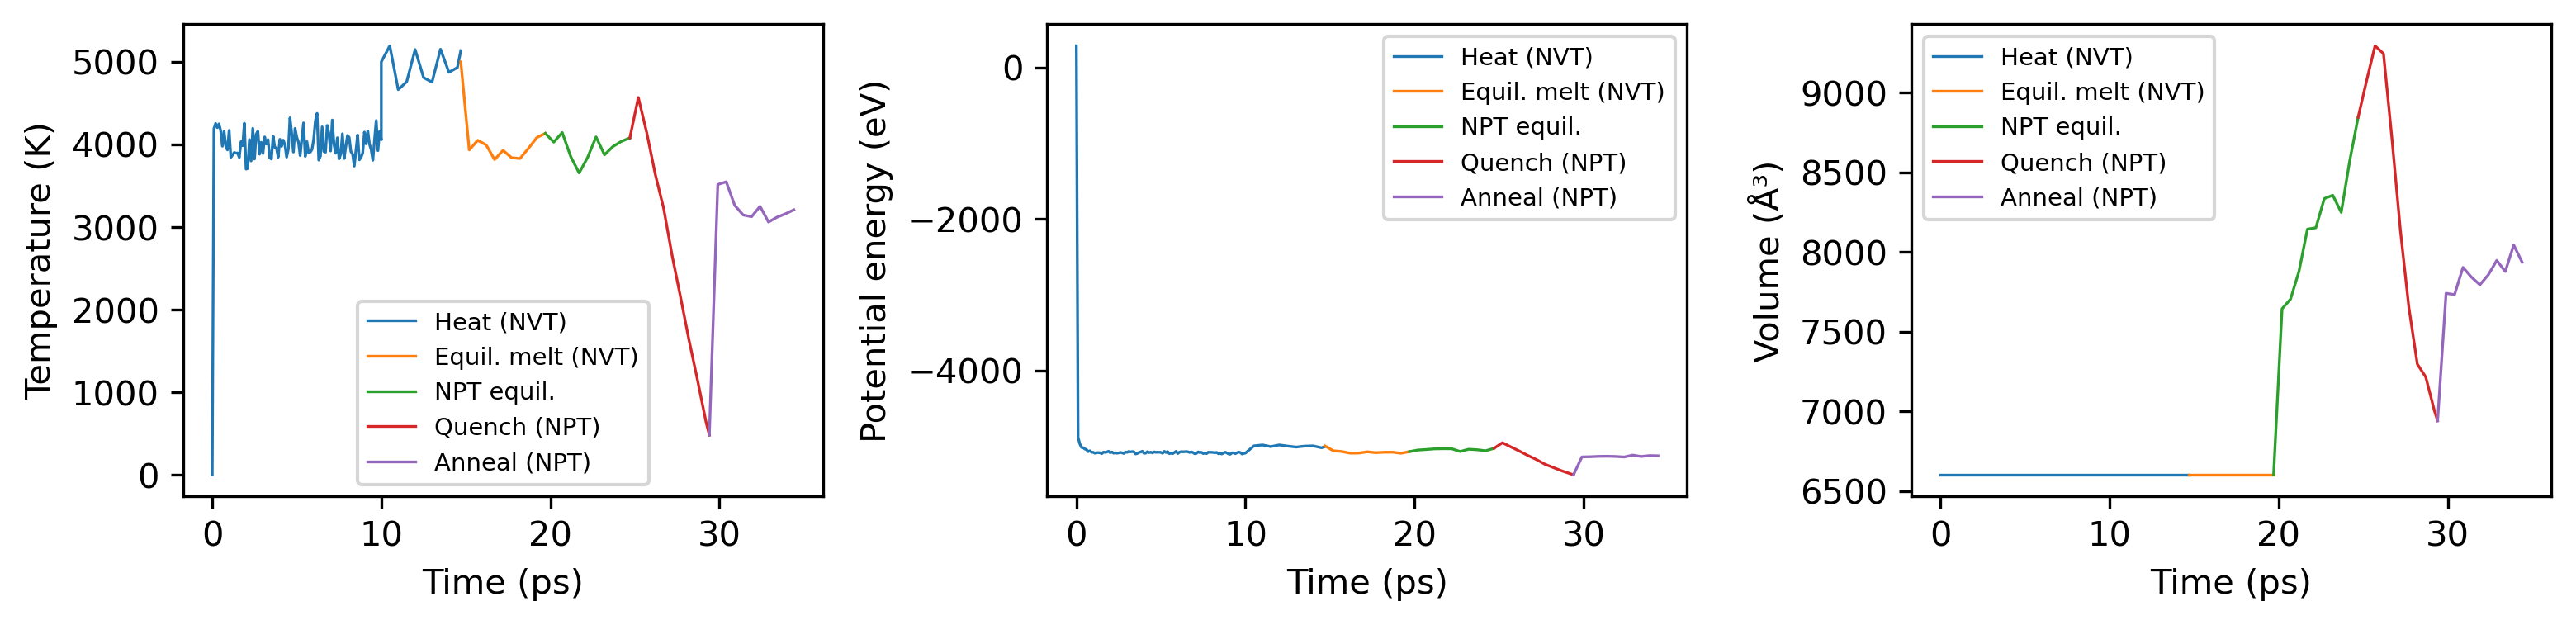

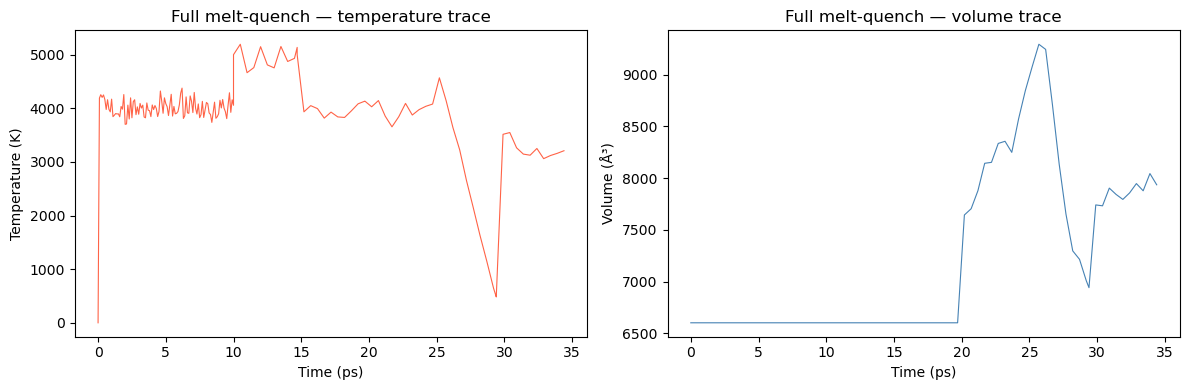

In [11]:
# Per-stage view — each stage has its own colour
shik_stage_labels = ["Heat (NVT)", "Equil. melt (NVT)", "NPT equil.", "Quench (NPT)", "Anneal (NPT)"]
plot_schedule(history, labels=shik_stage_labels)

# Continuous trace using merge_thermo
merged = merge_thermo(history)
time_ps = merged["steps"] * 1e-3  # 1 fs timestep → ps

_fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(time_ps, merged["temperature"], lw=0.8, color="tomato")
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Full melt-quench — temperature trace")

axes[1].plot(time_ps, merged["volume"], lw=0.8, color="steelblue")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Volume (Å³)")
axes[1].set_title("Full melt-quench — volume trace")

plt.tight_layout()
plt.show()

### Density from the equilibrated structure

The volume of the simulation box after NPT relaxation gives the glass density directly.

In [12]:
from ase.data import atomic_masses


def compute_density(structure):
    """Density in g/cm³ from an ASE Atoms object."""
    mass_amu = sum(atomic_masses[n] for n in structure.get_atomic_numbers())
    volume_A3 = structure.get_volume()
    mass_g = mass_amu * 1.66054e-24
    volume_cm3 = volume_A3 * 1e-24
    return mass_g / volume_cm3


rho = compute_density(glass)
print(f"Glass density: {rho:.3f} g/cm³")

Glass density: 2.236 g/cm³


### Structural analysis

After the melt-quench the final `Atoms` structure can be passed directly to the analysis tools. See `StructureTutorial.ipynb` for a full walkthrough; here is a quick RDF check.

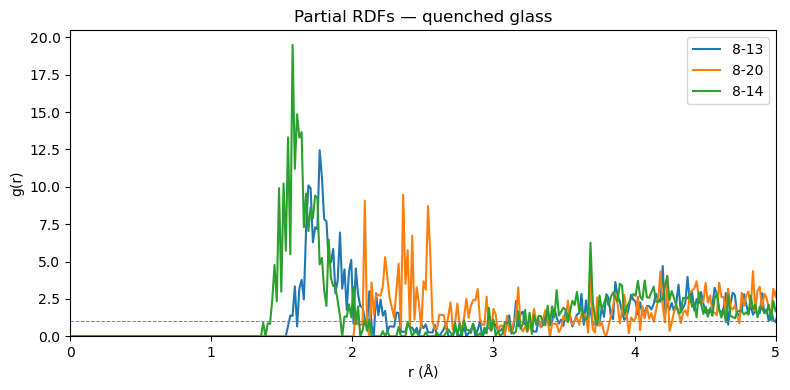

In [13]:
# Quick RDF for the quenched glass
# atom types: Ca=20, Al=13, Si=14, O=8
r, rdfs, cn = am.compute_rdf(
    structure=glass,
    r_max=8.0,
    n_bins=500,
    type_pairs=[(14, 8), (13, 8), (20, 8)],  # Si-O, Al-O, Ca-O
)

fig, ax = plt.subplots(figsize=(8, 4))
labels = {(14, 8): "Si-O", (13, 8): "Al-O", (20, 8): "Ca-O"}
for (zi, zj), g in rdfs.items():
    ax.plot(r, g, label=labels.get((zi, zj), f"{zi}-{zj}"))
ax.axhline(1, ls="--", color="gray", lw=0.7)
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.set_title("Partial RDFs — quenched glass")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Quick Reference

### Functions

| Function | Signature | Returns |
|----------|-----------|---------|
| `get_structure_dict` | `(composition, target_atoms, mode="molar")` | `dict` with `"atoms"`, `"box"` |
| `get_ase_structure` | `(atoms_dict, replicate=(1,1,1))` | `ase.Atoms` |
| `select_potential` | `(elements: set[str])` | `str \| None` |
| `compatible_potentials` | `(elements: set[str])` | `list[str]` |
| `get_supported_elements` | `(potential_type: str)` | `set[str]` |
| `generate_potential` | `(atoms_dict, potential_type="pmmcs", melt=True)` | `pd.DataFrame` |
| `melt_quench_simulation` | `(structure, potential, *, temperature_high, temperature_low, heating_rate, cooling_rate, ...)` | `{"structure": Atoms, "result": list[dict \| None]}` |

### Potential quick-pick

```
B in system?          → SHIK
Transition metals?    → PMMCS (check coverage)
Strictly Ca/Al/Si/O?  → BJP (or PMMCS — both work)
Everything else?      → PMMCS
```

### Output structure

```python
result  = melt_quench_simulation(...)
glass   = result["structure"]   # ASE Atoms — pass to analysis functions
history = result["result"]      # list[dict | None] — one thermo dict per protocol stage

# Inspect a single stage
stage_1 = history[0]            # keys: steps, temperature, pot_energy, volume, ...

# Continuous trace across all stages
merged  = merge_thermo(history) # same keys, steps monotonically increasing

# Visualise
plot_schedule(history, labels=["Heat", "Equil.", "Quench", ...])
```

For custom multi-stage cooling or annealing schedules, see **MDTutorial.ipynb**.